In [1]:
import sys
sys.path.append(r'C:\Users\Lenovo\Desktop\2025_E\tools/')
from IM_dataset import IM_dataset
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator
from mxnet import np, npx
npx.set_np()

In [2]:
IM_data = IM_dataset(1000)

In [3]:
batch_size = 16
data_loader = LoadArray(IM_data,batch_size)

In [4]:
test_data = np.array([[12.2,
14.3,
16.52,
18.87,
20.25,
20.1,
22.3,
24,
23.6,
24.8,
25.1,
27.2,
26.1,
27.7,
29.2,
27.4,
28.7,
30,
28.9,
30.01,
32.1,
28.8
]])

In [5]:
model = gluon.nn.Sequential()
model.add(

    # gluon.nn.Dense(64, activation='relu'),
    gluon.nn.Dense(3),
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [6]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'adam',{'learning_rate':0.0001})

In [7]:
best_loss = float(100)

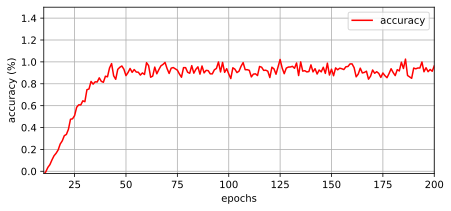

In [8]:
epochs = 200
animator = Animator(xlabel='epochs',ylabel='accuracy (%)',legend=['accuracy'],xlim=[10,epochs],ylim=[-0.02,1.5],figsize=(7,3),fmts='r:')
for epoch in range(epochs):
    epoch_loss = 0
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
            test_output = model(feature)
            test_accuracy = np.mean(test_output / test_data)
    animator.add(epoch+1, (test_accuracy-0.15,))

In [9]:

feature = np.array([[2.26,	119.62,	2.29


]])
model(feature)

array([[27.801235]])

In [10]:
model[0].weight.data()

array([[-0.35343525, -0.28035966, -0.39704826],
       [ 0.36546615,  0.2626823 ,  0.39783815],
       [-0.3406382 , -0.2571665 , -0.38510638]])

In [11]:
model[1].weight.data()

array([[-0.26483557,  0.27510536, -0.289518  ]])

In [12]:
model[1].bias.data()

array([-0.04960654])

D:\Anaconda\envs\d2l\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  """


Text(0, 0.5, 'LSR (%)')

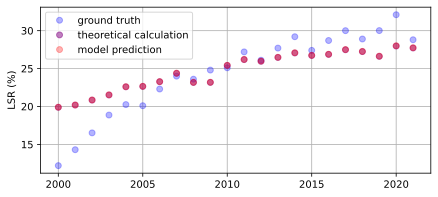

In [13]:
import sys
sys.path.append(r'E:\d2l_tools\d2l_tools(MXNet)\draw')
from plot import plot
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
ground_truth = np.array([
    12.2, 14.3, 16.52, 18.87, 20.25, 20.1, 22.3, 24, 23.6, 24.8, 25.1, 27.2, 
    26.1, 27.7, 29.2, 27.4, 28.7, 30, 28.9, 30.01, 32.1, 28.8
])

model_prediction = np.array([
    19.91, 20.2, 20.86, 21.54, 22.61, 22.67, 23.28, 24.40, 23.19, 23.20, 
    25.43, 26.21, 25.99, 26.49, 27.09, 26.75, 26.890, 27.51, 27.27, 26.64, 
    28.010, 27.75
])

calculate = np.array([
    19.89075, 20.18578, 20.84203, 21.51557, 22.59179, 22.64116, 23.27172, 
    24.36821, 23.16456, 23.17133, 25.4084, 26.18374, 25.95702, 26.4656, 
    27.05698, 26.72168, 26.86703, 27.48062, 27.23755, 26.61024, 27.96881, 
    27.71156
])


year =  np.array([
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
    2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
    2020, 2021
])

plt.figure(figsize=(7,3))
plt.plot(year, ground_truth, 'o',alpha=0.3,label='ground truth',color='blue')
plt.plot(year, calculate, 'o',alpha=0.5,label='theoretical calculation',color='purple')
plt.plot(year, model_prediction, 'o',alpha=0.3,label='model prediction',color='red')
plt.legend()
plt.grid(True)
plt.ylabel('LSR (%)')

D:\Anaconda\envs\d2l\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  """


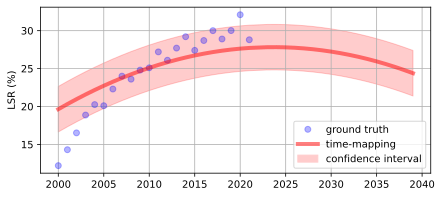

In [14]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')
sys.path.append(r'E:\d2l_tools\d2l_tools(MXNet)\draw')
from plot import plot

# 数据
ground_truth = np.array([
    12.2, 14.3, 16.52, 18.87, 20.25, 20.1, 22.3, 24, 23.6, 24.8, 25.1, 27.2, 
    26.1, 27.7, 29.2, 27.4, 28.7, 30, 28.9, 30.01, 32.1, 28.8
])

year_1 =  np.array([
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
    2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
    2020, 2021
])

year_2 = np.array([
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
    2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
    2020, 2021, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,2031,2032,2033,2034,2035,2036,2037,2038,2039
])

def f(x):
    return (-0.01462044487*x**2+59.17365663*x-59845.89449)

# 计算拟合值和置信区间
y_fit = f(year_2)
confidence_interval = 3
plt.figure(figsize=(7,3))
# 绘制数据点和拟合曲线
plt.plot(year_1, ground_truth, 'o', alpha=0.3, label='ground truth', color='blue')
plt.plot(year_2, y_fit, alpha=0.5, label='time-mapping', color='red', linewidth=4)

# 绘制置信区间
plt.fill_between(year_2, y_fit - confidence_interval, y_fit + confidence_interval, color='red', alpha=0.2, label='confidence interval')

# 添加图例和标签
plt.legend()
plt.ylabel('LSR (%)')
plt.grid(True)
# 显示图形
plt.show()

D:\Anaconda\envs\d2l\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  """


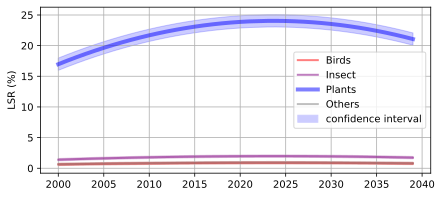

In [21]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg')

sys.path.append(r'E:\d2l_tools\d2l_tools(MXNet)\draw')
from plot import plot

# 数据
ground_truth = np.array([
    12.2, 14.3, 16.52, 18.87, 20.25, 20.1, 22.3, 24, 23.6, 24.8, 25.1, 27.2, 
    26.1, 27.7, 29.2, 27.4, 28.7, 30, 28.9, 30.01, 32.1, 28.8
])

year_1 =  np.array([
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
    2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
    2020, 2021
])

year_2 = np.array([
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
    2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
    2020, 2021, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,2031,2032,2033,2034,2035,2036,2037,2038,2039
])

def f_birds(x):
    return (-0.01462044487*x**2+59.17365663*x-59845.89449)*0.032

def f_insect(x):
    return (-0.01462044487*x**2+59.17365663*x-59845.89449)*0.071

def f_plants(x):
    return (-0.01462044487*x**2+59.17365663*x-59845.89449)*0.864

def f_others(x):
    return (-0.01462044487*x**2+59.17365663*x-59845.89449)*0.033
# 计算拟合值和置信区间

f_fit_birds = f_birds(year_2)
f_fit_insect = f_insect(year_2)
f_fit_plants = f_plants(year_2)
f_fit_others = f_others(year_2)

confidence_interval = 0.2
plt.figure(figsize=(7,3))
# 绘制数据点和拟合曲线
# plt.plot(year_1, ground_truth, 'o', alpha=0.3, label='ground truth', color='blue')
plt.plot(year_2, f_fit_birds, alpha=0.5, label='Birds', color='red', linewidth=2)
plt.plot(year_2, f_fit_insect, alpha=0.5, label='Insect', color='purple', linewidth=2)
plt.plot(year_2, f_fit_plants, alpha=0.5, label='Plants', color='blue', linewidth=4)
plt.plot(year_2, f_fit_others, alpha=0.5, label='Others', color='grey', linewidth=2)


# 绘制置信区间
plt.fill_between(year_2, f_fit_birds - confidence_interval, f_fit_birds + confidence_interval, color='red', alpha=0.2)
plt.fill_between(year_2, f_fit_insect - confidence_interval, f_fit_insect + confidence_interval, color='purple', alpha=0.2)
plt.fill_between(year_2, f_fit_plants - 1, f_fit_plants + 1, color='blue', alpha=0.2, label='confidence interval')
plt.fill_between(year_2, f_fit_others - confidence_interval, f_fit_others + confidence_interval, color='grey', alpha=0.2)


# 添加图例和标签
plt.legend()
plt.ylabel('LSR (%)')
plt.grid(True)
# 显示图形
plt.show()

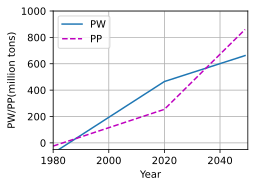

In [16]:
from mxnet import np,npx
npx.set_np()

# def PW(x):
#     return 13.5698 * x - 26945.79

def PW(x):
    return np.where(x < 2020, 13.5698 * x - 26945.79, 6.7849 * x - 13240.29)

#def PP(x):
 #   return 6.9615 * x - 13807.91
def PP(x):
    return np.where(x < 2020, 6.9615 * x - 13807.91, 20.8845 * x - 41932.37)

a = np.arange(1980,2050,1)
pw = PW(a)
pp = PP(a)

x = tuple(a.tolist())
pw = tuple(pw.asnumpy().tolist())
pp = tuple(pp.asnumpy().tolist())

animator_2 = Animator(xlabel='Year',ylabel='PW/PP(million tons)',legend=['PW','PP'],xlim=[1980,2050],ylim=[-50,1000])
for i, pw_val,pp_val in zip(x,pw,pp):
    animator_2.add(i,[pw_val,pp_val])

In [17]:
def pascal_triangle(n):
    triangle = np.zeros((n, n), dtype=int)
    for i in range(n):
        triangle[i, 0] = 1
        triangle[0, i] = 1
    for i in range(1, n):
        for j in range(1, n):
            triangle[i, j] = triangle[i-1, j] + triangle[i, j-1]
    return triangle


In [18]:
traingle = pascal_triangle(11)
traingle

array([[     1,      1,      1,      1,      1,      1,      1,      1,
             1,      1,      1],
       [     1,      2,      3,      4,      5,      6,      7,      8,
             9,     10,     11],
       [     1,      3,      6,     10,     15,     21,     28,     36,
            45,     55,     66],
       [     1,      4,     10,     20,     35,     56,     84,    120,
           165,    220,    286],
       [     1,      5,     15,     35,     70,    126,    210,    330,
           495,    715,   1001],
       [     1,      6,     21,     56,    126,    252,    462,    792,
          1287,   2002,   3003],
       [     1,      7,     28,     84,    210,    462,    924,   1716,
          3003,   5005,   8008],
       [     1,      8,     36,    120,    330,    792,   1716,   3432,
          6435,  11440,  19448],
       [     1,      9,     45,    165,    495,   1287,   3003,   6435,
         12870,  24310,  43758],
       [     1,     10,     55,    220,    715,   2002,